In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [12]:
df = pd.read_csv('../data/merged_data/merged_master_df.csv')

Liczba dni do analizy po usunięciu braków: 25


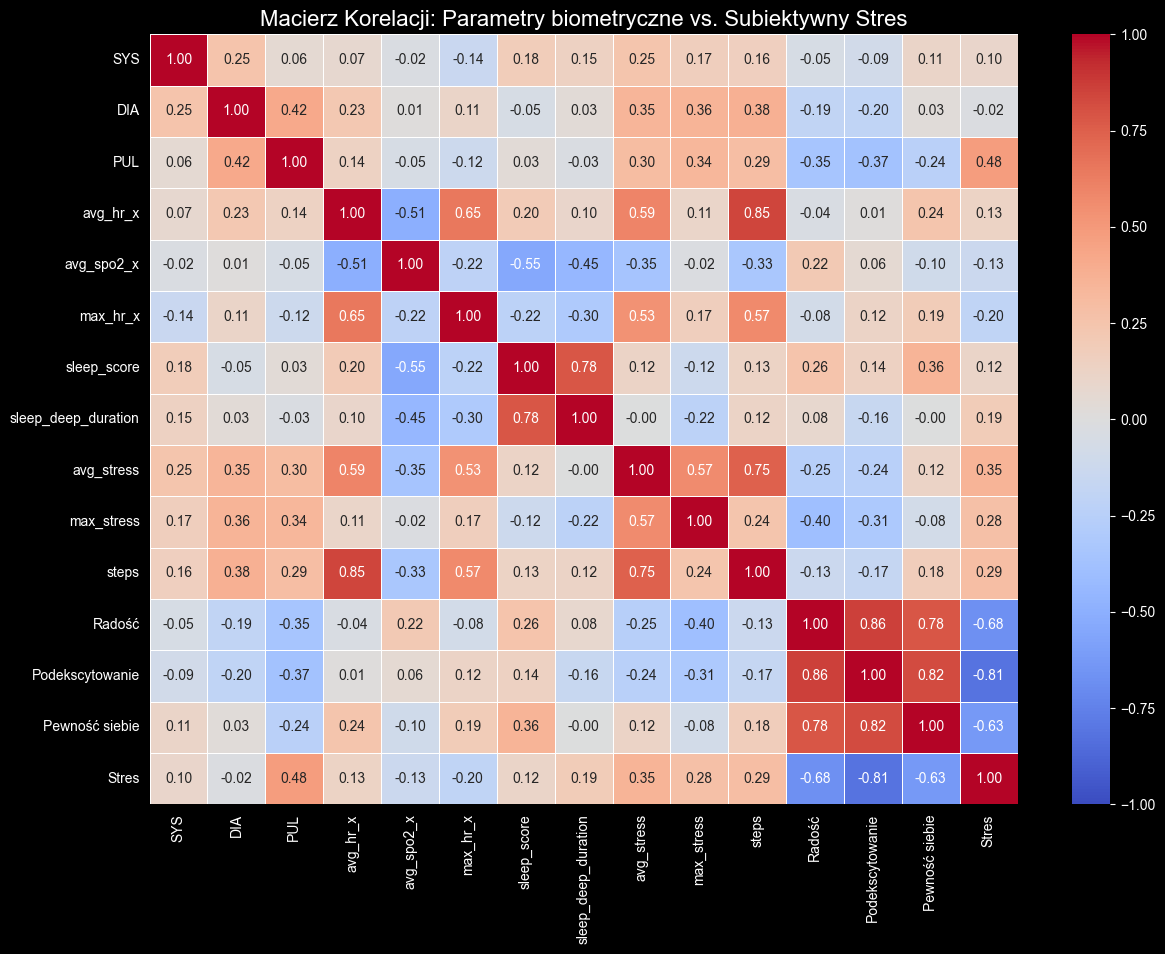

In [13]:
# 2. Wybór kolumn do analizy (zbyt duża liczba kolumn sprawi, że mapa będzie nieczytelna)
# Wybieramy reprezentantów każdej grupy: ciśnienie, sp02, HR, stres (urządzenie), sen i Twoje ankiety
selected_columns = [
    'SYS', 'DIA', 'PUL',                       # Ciśnienie
    'avg_hr_x', 'avg_spo2_x', 'max_hr_x',                  # Biometria (dzień)
    'sleep_score', 'sleep_deep_duration',      # Sen
    'avg_stress', 'max_stress',                     # Stres (urządzenie)
    'steps',                                   # Aktywność
    'Radość', 'Podekscytowanie', 'Pewność siebie', 'Stres'       # Ankiety (Target)
]

# Tworzymy podzbiór danych
df_analysis = df[selected_columns].copy()
# 3. CZYSZCZENIE: Usuwamy wiersze, które mają chociaż jedno NaN w wybranych kolumnach
# To kluczowe, bo korelacja Pearsona nie zadziała poprawnie na brakach danych
df_clean = df_analysis.dropna()

print(f"Liczba dni do analizy po usunięciu braków: {len(df_clean)}")

# 4. Obliczanie macierzy korelacji
corr_matrix = df_clean.corr()

# 5. Rysowanie Heat Mapy
plt.figure(figsize=(14, 10))
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Maska, aby ukryć górny trójkąt (powtarzające się dane)

heatmap = sns.heatmap(
    corr_matrix,
    annot=True,           # Wyświetla wartości r w kwadratach
    fmt=".2f",
    cmap='coolwarm',      # Niebieski (ujemna), Czerwony (dodatnia)
    vmin=-1, vmax=1,
    center=0,
    linewidths=.5
)

plt.title('Macierz Korelacji: Parametry biometryczne vs. Subiektywny Stres', fontsize=16)
plt.show()

Druga macierz korelacji

Liczba dni do analizy po usunięciu braków: 25


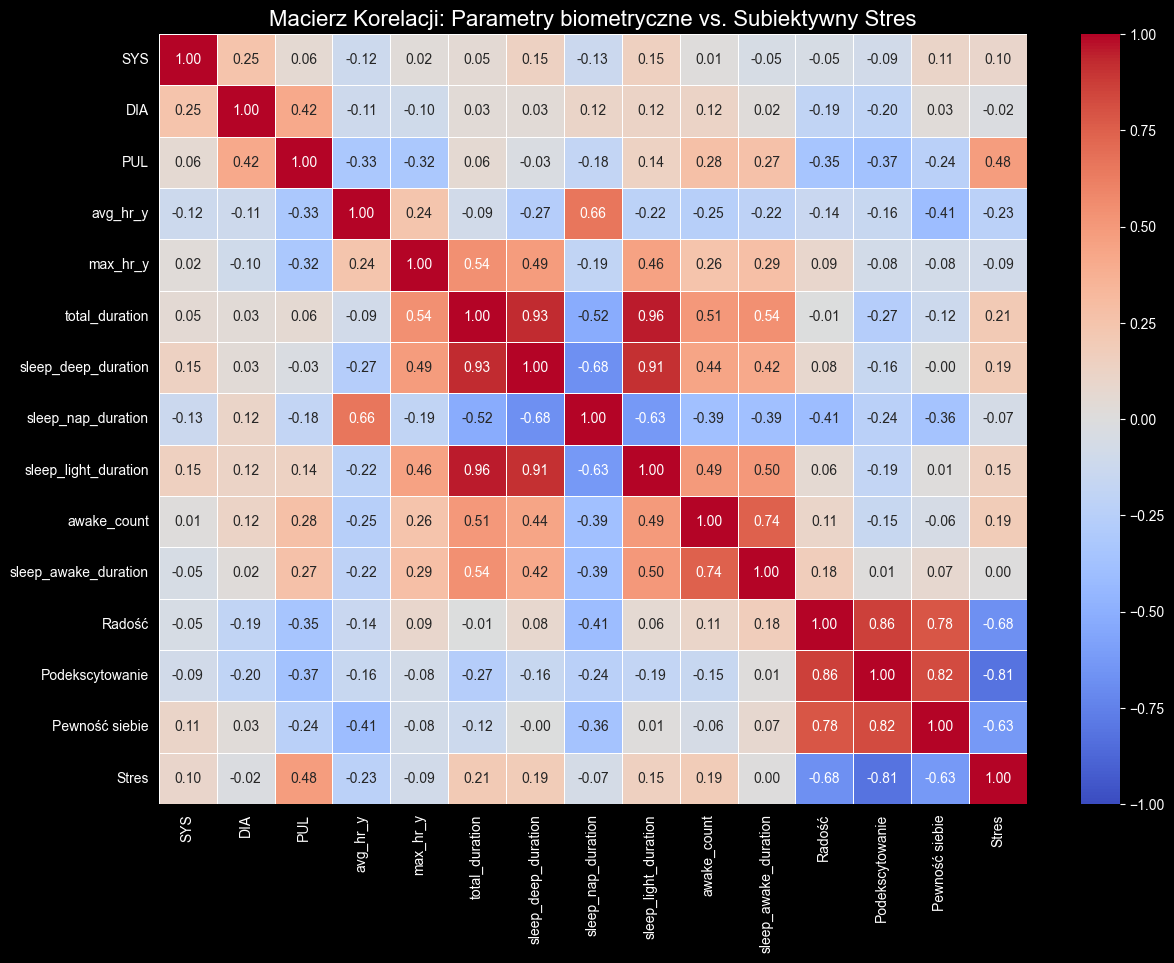

In [14]:
# 2. Wybór kolumn do analizy
# Wybieramy reprezentantów każdej grupy: ciśnienie, sp02, HR, stres (urządzenie), sen i Twoje ankiety
selected_columns = [
    'SYS', 'DIA', 'PUL',                       # Ciśnienie
    'avg_hr_y', 'max_hr_y',                 # Biometria (noc)
    'total_duration', 'sleep_deep_duration', 'sleep_nap_duration', 'sleep_light_duration', 'awake_count', 'sleep_awake_duration',    # Sen
    'Radość', 'Podekscytowanie', 'Pewność siebie', 'Stres'       # Ankiety (Target)
]

# Tworzymy podzbiór danych
df_analysis = df[selected_columns].copy()
# 3. CZYSZCZENIE: Usuwamy wiersze, które mają chociaż jedno NaN w wybranych kolumnach
# To kluczowe, bo korelacja Pearsona nie zadziała poprawnie na brakach danych
df_clean = df_analysis.dropna()

print(f"Liczba dni do analizy po usunięciu braków: {len(df_clean)}")

# 4. Obliczanie macierzy korelacji
corr_matrix = df_clean.corr()

# 5. Rysowanie Heat Mapy
plt.figure(figsize=(14, 10))
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Maska, aby ukryć górny trójkąt (powtarzające się dane)

heatmap = sns.heatmap(
    corr_matrix,
    annot=True,           # Wyświetla wartości r w kwadratach
    fmt=".2f",
    cmap='coolwarm',      # Niebieski (ujemna), Czerwony (dodatnia)
    vmin=-1, vmax=1,
    center=0,
    linewidths=.5
)

plt.title('Macierz Korelacji: Parametry biometryczne vs. Subiektywny Stres', fontsize=16)
plt.show()